# hw2: Решающие деревья

*Спасибо великому курсу великого Евгения Соколова*

### О задании

Задание состоит из двух разделов:
1. В первом разделе вы научитесь применять деревья из sklearn для задачи классификации. Вы посмотрите какие разделяющие поверхности деревья строят для различных датасетов и проанализируете их зависимость от различных гиперпараметров.
2. Во втором разделе вы попробуете реализовать свое решающее дерево и сравните его со стандартное имплементацией из sklearn. Вы также протестируете деревья на более сложных датасетах и сравните различные подходы к кодированию категориальных признаков.

Все данные, на которых будут обучаться модели, вы можете найти на диске.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов. Неэффективная и/или неоригинальная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Заполненный ноутбук ```hw2-trees.ipynb``` и модуль с реализованными функциями и классами ```hw2code.py``` необходимо загрузить на свой Github. Затем нужно оставить комментарий в Google-таблице с оценками в столбце <<hw2>> в строке со своей фамилией о том, что вы выполнили работу с указанием ника на Kaggle. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим два простых двумерных датасета сделанных с помощью `make_moons`, `make_circles` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

In [2]:
from sklearn.datasets import make_moons, make_circles, make_classification
datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, class_sep=.8, random_state=3,
                        n_redundant=0, )
]

In [3]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

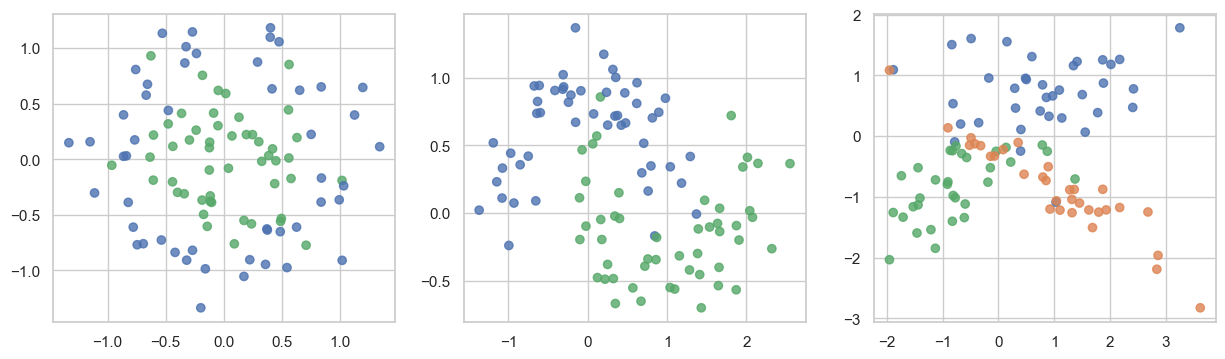

In [4]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=.8)

__Задание 1. (1 балл)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

In [18]:
def plot_surface(tree, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

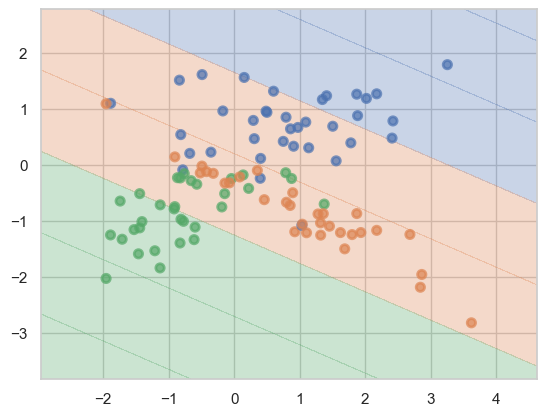

In [6]:
# Пример:
from sklearn.linear_model import LinearRegression
X, y = datasets[2]
lr  = LinearRegression().fit(X, y)
plot_surface(lr, X, y)

Dataset 1: Train accuracy = 1.0000, Test accuracy = 0.7333, Разница = 0.2667
Dataset 2: Train accuracy = 1.0000, Test accuracy = 0.8667, Разница = 0.1333
Dataset 3: Train accuracy = 1.0000, Test accuracy = 0.8333, Разница = 0.1667


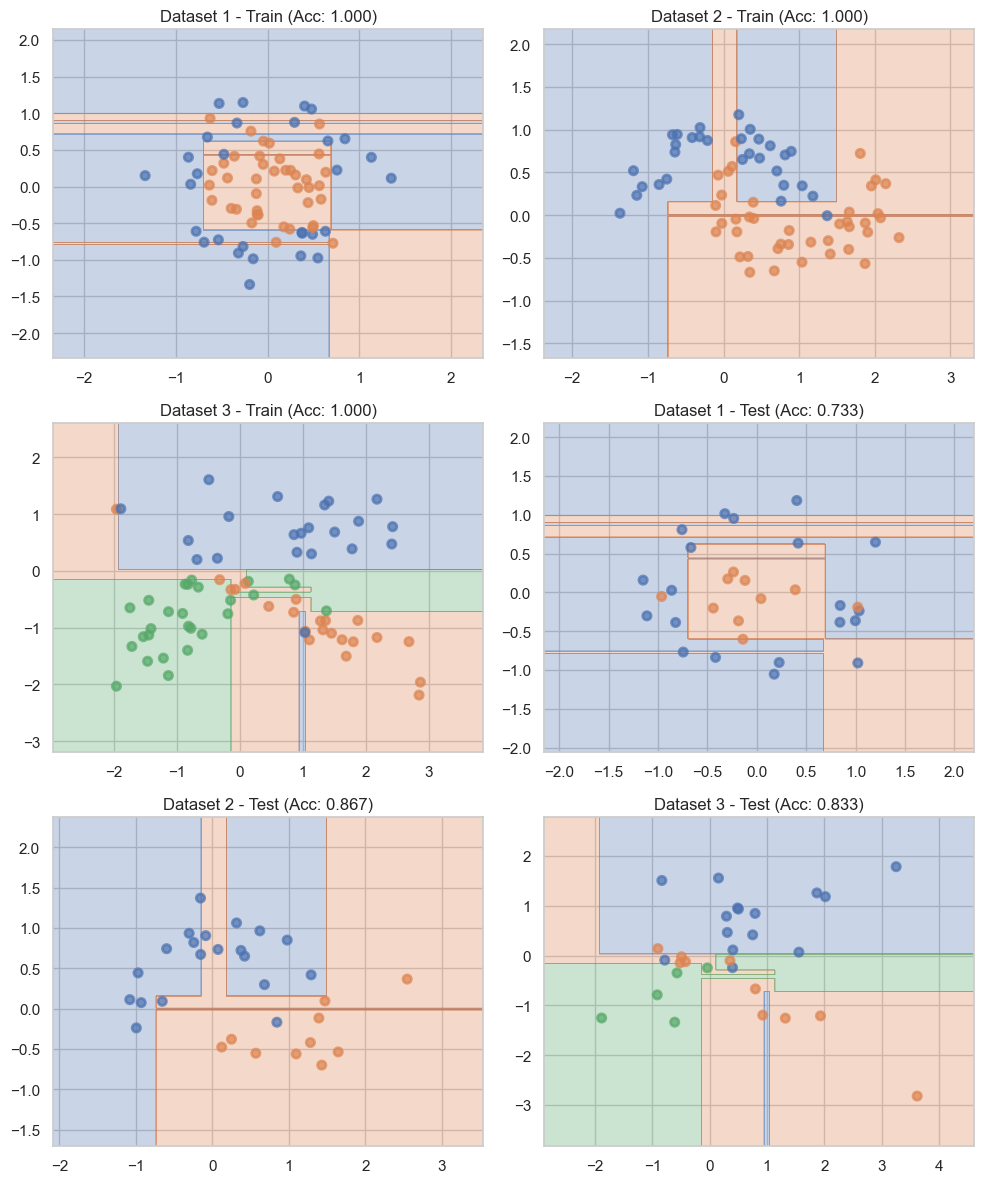

In [8]:
from sklearn.metrics import accuracy_score

plt.figure(figsize=(10, 12))

for i, (X, y) in enumerate(datasets):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    tree = DecisionTreeClassifier(random_state=42)
    tree.fit(X_train, y_train)

    train_accuracy = accuracy_score(y_train, tree.predict(X_train))
    test_accuracy = accuracy_score(y_test, tree.predict(X_test))


    plt.subplot(3, 2, i + 1)
    plot_surface(tree, X_train, y_train)
    plt.title(f'Dataset {i+1} - Train (Acc: {train_accuracy:.3f})')

    plt.subplot(3, 2, i + 4)
    plot_surface(tree, X_test, y_test)
    plt.title(f'Dataset {i+1} - Test (Acc: {test_accuracy:.3f})')

    print(f'Dataset {i+1}: Train accuracy = {train_accuracy:.4f}, Test accuracy = {test_accuracy:.4f}, Разница = {train_accuracy - test_accuracy:.4f}')
plt.tight_layout()

__Ответ:__Деревья сильно переобучились

__Задание 2. (1.5 балла)__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?


== Dataset 1 ==
max_depth=2: Train=0.8286, Test=0.6333, Разница=0.1952
max_depth=5: Train=0.9714, Test=0.7667, Разница=0.2048
min_samples_leaf=10: Train=0.8143, Test=0.7667, Разница=0.0476
min_samples_leaf=20: Train=0.6857, Test=0.7333, Разница=-0.0476


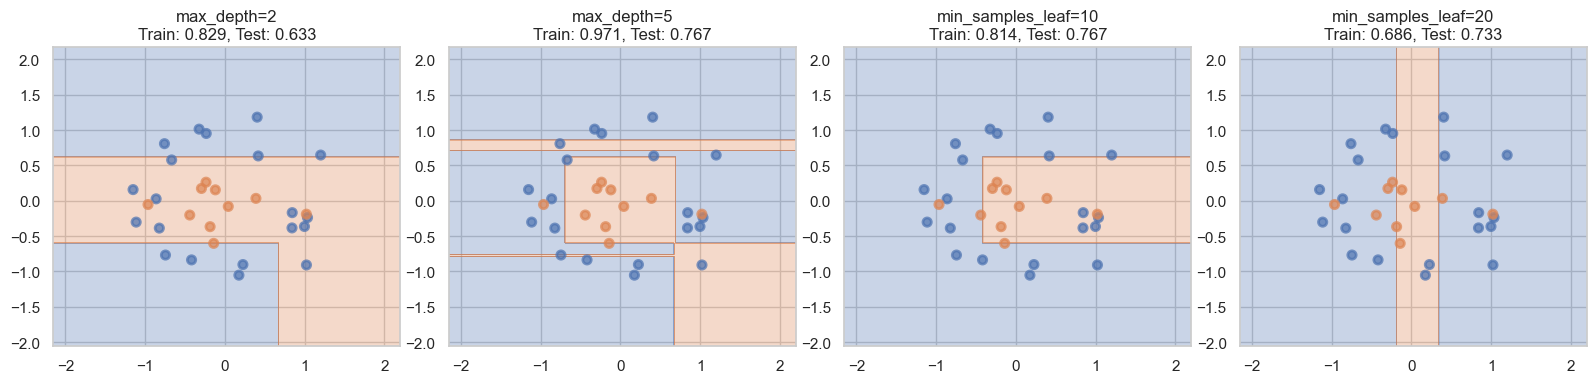


== Dataset 2 ==
max_depth=2: Train=0.9143, Test=0.9333, Разница=-0.0190
max_depth=5: Train=1.0000, Test=0.8667, Разница=0.1333
min_samples_leaf=10: Train=0.8714, Test=0.7667, Разница=0.1048
min_samples_leaf=20: Train=0.8429, Test=0.8000, Разница=0.0429


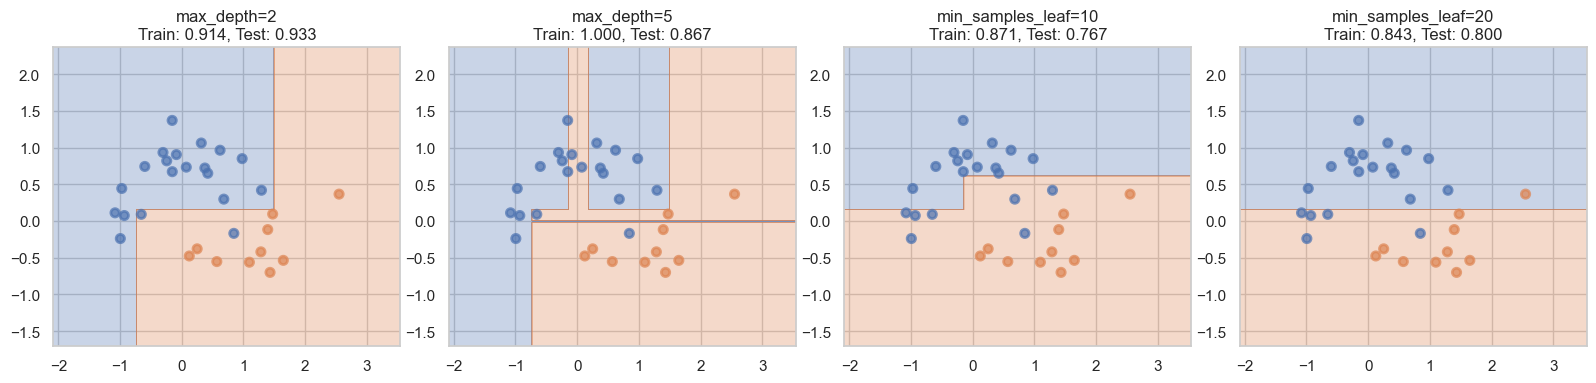


== Dataset 3 ==
max_depth=2: Train=0.9000, Test=0.7667, Разница=0.1333
max_depth=5: Train=0.9714, Test=0.8000, Разница=0.1714
min_samples_leaf=10: Train=0.8857, Test=0.7667, Разница=0.1190
min_samples_leaf=20: Train=0.8857, Test=0.7667, Разница=0.1190


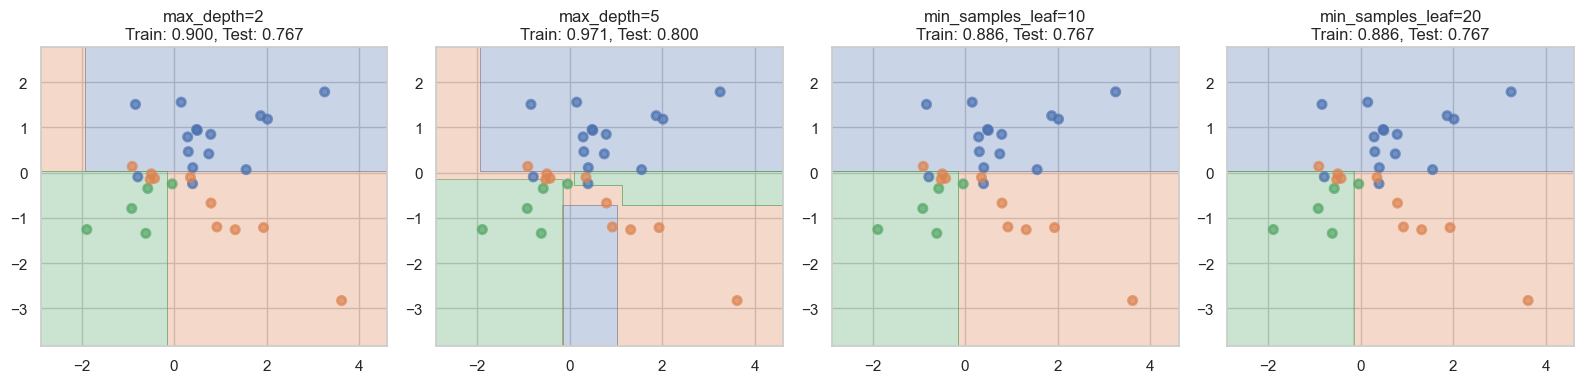

In [9]:
params_list = [
    {"max_depth": 2, 'name': 'max_depth=2'},
    {"max_depth": 5, 'name': 'max_depth=5'},
    {"min_samples_leaf": 10, 'name': 'min_samples_leaf=10'},
    {"min_samples_leaf": 20, 'name': 'min_samples_leaf=20'}
]

for dataset_idx, (X, y) in enumerate(datasets):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    print(f"\n== Dataset {dataset_idx + 1} ==")

    plt.figure(figsize=(16, 4))

    for i, params in enumerate(params_list):
        param_dict = {k: v for k, v in params.items() if k != 'name'}
        tree = DecisionTreeClassifier(random_state=42, **param_dict)
        tree.fit(X_train, y_train)

        train_accuracy = accuracy_score(y_train, tree.predict(X_train))
        test_accuracy = accuracy_score(y_test, tree.predict(X_test))

        plt.subplot(1, 4, i + 1)
        plot_surface(tree, X_test, y_test)
        plt.title(f"{params['name']}\nTrain: {train_accuracy:.3f}, Test: {test_accuracy:.3f}")
        print(f"{params['name']}: Train={train_accuracy:.4f}, Test={test_accuracy:.4f}, Разница={train_accuracy-test_accuracy:.4f}")

    plt.tight_layout()
    plt.show()

Ответ: Регуляризация по-разному влияет на различные наборы данных из-за их особенностей. Второй набор данных с простой границей разделения идеально работает с max_depth=2, в то время как первый набор со сложной круговой границей требует более тонкой регуляризации через min_samples_leaf. Третий набор данных демонстрирует устойчивость к переобучению, что показывает, как его структура плохо соответствует оси-параллельным разделениям деревьев. Разделяющие поверхности упрощаются - убираются излишние градации, но эффективность зависит от соответствия сложности модели истинной структуре данных.

# 2. Решающие деревья своими руками

В этой части вам нужно реализовать свой класс для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__Задание 3. (1.5 балл)__

Реализуйте функцию find_best_split из модуля hw2code.py

__Задание 4. (0.5 балла)__

Загрузите таблицу students.csv (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака — класс" для всех пяти признаков.

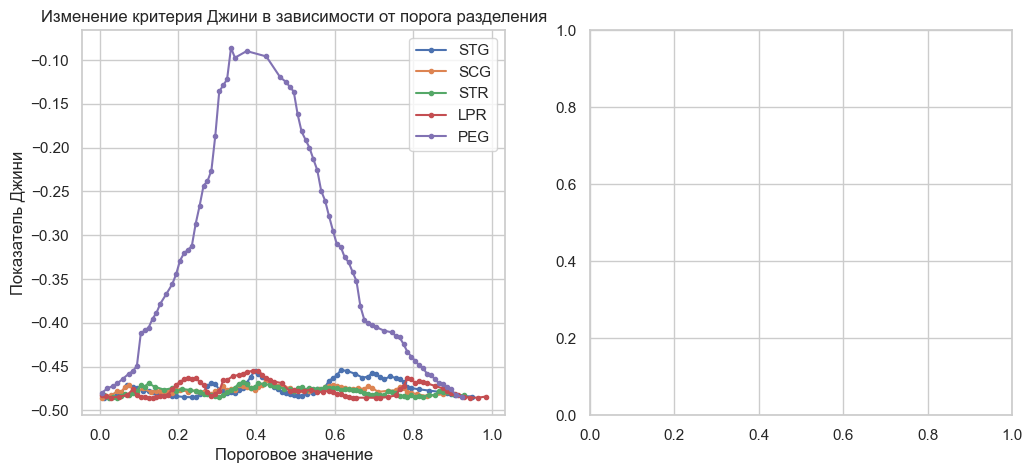

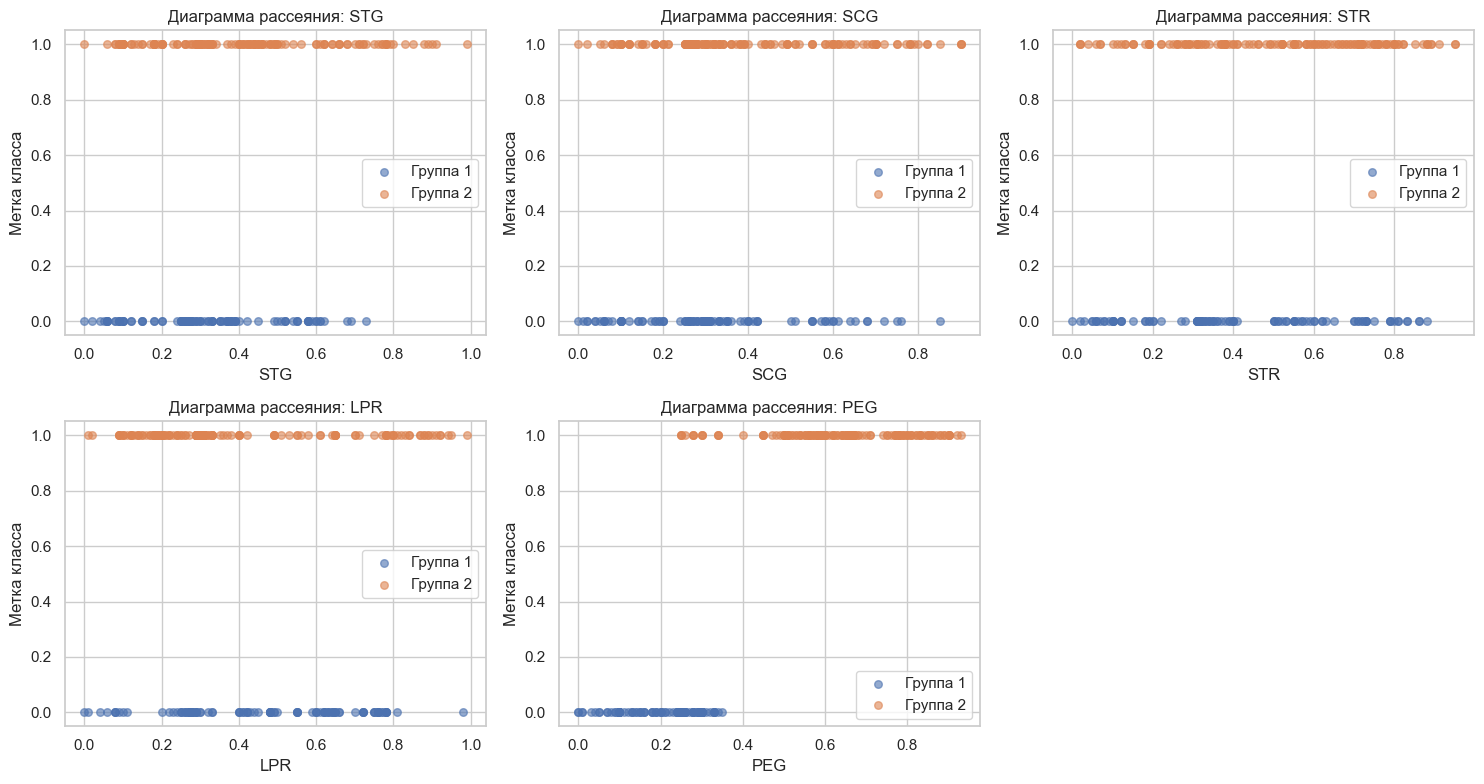

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from hw2.hw2code import find_best_split

df = pd.read_csv('../datasets/students.csv')
features = df.iloc[:, :-1].values
target = df.iloc[:, -1].values
column_names = df.columns[:-1]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for col_idx in range(features.shape[1]):
    split_points, quality_metrics, best_split, best_quality = find_best_split(features[:, col_idx], target)
    plt.plot(split_points, quality_metrics, label=column_names[col_idx], marker='o', markersize=3)

plt.xlabel('Пороговое значение')
plt.ylabel('Показатель Джини')
plt.title('Изменение критерия Джини в зависимости от порога разделения')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
figure, subplots = plt.subplots(2, 3, figsize=(15, 8))
subplots = subplots.flatten()

for col_idx in range(features.shape[1]):
    subplots[col_idx].scatter(features[target == 0, col_idx], target[target == 0], alpha=0.6, label='Группа 1', s=30)
    subplots[col_idx].scatter(features[target == 1, col_idx], target[target == 1], alpha=0.6, label='Группа 2', s=30)
    subplots[col_idx].set_xlabel(column_names[col_idx])
    subplots[col_idx].set_ylabel('Метка класса')
    subplots[col_idx].set_title(f'Диаграмма рассеяния: {column_names[col_idx]}')
    subplots[col_idx].legend()
    subplots[col_idx].grid(True)

if len(subplots) > features.shape[1]:
    subplots[-1].remove()

plt.tight_layout()
plt.show()

__Задание 5. (0.5 балла)__

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой scatter-графиков? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

**Ответ: Признак PEG явно выделяется как наилучший кандидат для первого разбиения дерева. Его кривая критерия Джини демонстрирует выраженный пик, существенно превосходящий по высоте все остальные признаки. Это указывает на существование четкого оптимального порога разделения.
На scatter-графике для PEG хорошо видно, что классы разделяются достаточно четко - по разные стороны от границы преобладают разные классы.**

__Задание 6. (1.5 балла).__

Разберитесь с уже написанным кодом в классе DecisionTree модуля hw2code.py. Найдите ошибки в реализации метода \_fit_node. Напишите функцию \_predict_node.

 Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции. Выбор лучшего разбиения необходимо производить по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».

__Задание 7. (0.5 балла)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (лежит на гитхабе вместе с заданием), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [20]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from hw2.hw2code import DecisionTree

dataset = pd.read_csv('../datasets/agaricus-lepiota.data', header=None)

features = dataset.iloc[:, 1:].values
target = dataset.iloc[:, 0].values

encoder = LabelEncoder()
target_encoded = encoder.fit_transform(target)

for col_index in range(features.shape[1]):
    col_encoder = LabelEncoder()
    features[:, col_index] = col_encoder.fit_transform(features[:, col_index])

X_tr, X_te, y_tr, y_te = train_test_split(features, target_encoded, test_size=0.5, random_state=42)

feature_categories = ['categorical'] * features.shape[1]
model = DecisionTree(feature_categories)
model.fit(X_tr, y_tr)

predictions = model.predict(X_te)
score = accuracy_score(y_te, predictions)

print(f"Точность: {score:.4f}")
print(f"Верных предсказаний: {np.sum(predictions == y_te)} из {len(y_te)}")

Точность: 1.0000
Верных предсказаний: 4062 из 4062


__Задание 8. (бонус, 1 балл)__

Реализуйте в классе DecisionTree поддержку параметров max_depth, min_samples_split и min_samples_leaf по аналогии с DecisionTreeClassifier. Постройте графики зависимости качества предсказания в зависимости от этих параметров для набора данных tic-tac-toe (см. следующий пункт).

__Задание 9. (2 балла)__

Загрузите следующие наборы данных (напомним, что pandas умеет загружать файлы по url, в нашем случае это файл \*.data), предварительно ознакомившись с описанием признаков и целевой переменной в каждом из них (она записаны в Data Folder, в файле *.names): 
* [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom) (загрузили в предыдущем пункте, классы записаны в нулевом столбце)
* [tic-tac-toe](https://archive.ics.uci.edu/ml/datasets/Tic-Tac-Toe+Endgame) (классы записаны в последнем столбце, датасет лежит на гитхабе вместе с заданием)
* [cars](https://archive.ics.uci.edu/ml/datasets/Car+Evaluation) (классы записаны в последнем столбце, считаем что unacc, acc — это класс 0, good, vgood — класс 1)
* [nursery](https://archive.ics.uci.edu/ml/datasets/Nursery) (классы записаны в последнем столбце, считаем, что not_recom и recommend — класс 0, very_recom, priority, spec_prior — класс 1).

Закодируйте категориальные признаки, использовав LabelEncoder. С помощью cross_val_score (cv=10) оцените accuracy на каждом из этих наборов данных следующих алгоритмов:
* DecisionTree, считающий все признаки вещественными
* DecisionTree, считающий все признаки категориальными
* DecisionTree, считающий все признаки вещественными + one-hot-encoding всех признаков
* DecisionTreeClassifier из sklearn. Запишите результат в pd.DataFrame (по строкам — наборы данных, по столбцам — алгоритмы).

Рекомендации:
* Чтобы cross_val_score вычисляла точность, нужно передать scoring=make_scorer(accuracy_score), обе фукнции из sklearn.metrics.
* Если вам позволяет память (а она скорее всего позволяет), указывайте параметр sparse=False в OneHotEncoder (если вы, конечно, используете его). Иначе вам придется добиваться того, чтобы ваша реализация дерева умела работать с разреженными матрицами (что тоже, в целом, не очень сложно).

In [21]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
from hw2.hw2code import DecisionTree

experiment_data = {}

mushroom_data = pd.read_csv('../datasets/agaricus-lepiota.data', header=None)
mushroom_features = mushroom_data.iloc[:, 1:].values
mushroom_target = mushroom_data.iloc[:, 0].values
target_encoder = LabelEncoder()
mushroom_target_encoded = target_encoder.fit_transform(mushroom_target)

for col_idx in range(mushroom_features.shape[1]):
    feature_encoder = LabelEncoder()
    mushroom_features[:, col_idx] = feature_encoder.fit_transform(mushroom_features[:, col_idx])
experiment_data["mushrooms"] = (mushroom_features, mushroom_target_encoded)

game_data = pd.read_csv('../datasets/tic-tac-toe-endgame.csv', header=None)
game_features = game_data.iloc[:, :-1].values
game_target = game_data.iloc[:, -1].values
game_target_encoded = LabelEncoder().fit_transform(game_target)
for col_idx in range(game_features.shape[1]):
    game_encoder = LabelEncoder()
    game_features[:, col_idx] = game_encoder.fit_transform(game_features[:, col_idx])
experiment_data["tic-tac-toe"] = (game_features, game_target_encoded)

def evaluate_models(features, labels):
    performance = {}

    numeric_tree = DecisionTree(['real'] * features.shape[1])
    cv_scores = cross_val_score(numeric_tree, features, labels, cv=5, scoring=make_scorer(accuracy_score))
    performance['Tree_Real'] = cv_scores.mean()

    categorical_tree = DecisionTree(['categorical'] * features.shape[1])
    cv_scores = cross_val_score(categorical_tree, features, labels, cv=5, scoring=make_scorer(accuracy_score))
    performance['Tree_Categorical'] = cv_scores.mean()

    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoded_features = encoder.fit_transform(features)
    encoded_tree = DecisionTree(['real'] * encoded_features.shape[1])
    cv_scores = cross_val_score(encoded_tree, encoded_features, labels, cv=5, scoring=make_scorer(accuracy_score))
    performance['Tree_OneHot'] = cv_scores.mean()

    sklearn_tree = DecisionTreeClassifier(random_state=42)
    cv_scores = cross_val_score(sklearn_tree, features, labels, cv=5, scoring=make_scorer(accuracy_score))
    performance['Sklearn_Tree'] = cv_scores.mean()

    return performance

results_table = pd.DataFrame()
for dataset_name, (feature_matrix, target_vector) in experiment_data.items():
    print(f'Обработка {dataset_name}...')
    model_results = evaluate_models(feature_matrix, target_vector)
    results_table = pd.concat([results_table, pd.DataFrame([model_results], index=[dataset_name])])

print('\nИтоговые показатели:')
print(results_table)

Обработка mushrooms...
Обработка tic-tac-toe...

Итоговые показатели:
             Tree_Real  Tree_Categorical  Tree_OneHot  Sklearn_Tree
mushrooms     0.996799          0.988180     0.994335      0.961591
tic-tac-toe   0.410837          0.533666     0.523249      0.687407


__Задание 10. (1 балла)__

Проанализируйте результаты эксперимента. 
Одинаково ли для разных наборов данных ранжируются алгоритмы? 
Порассуждайте, почему так происходит. 

Обратите внимание на значение признаков в разных наборах данных. 
Присутствует ли в результатах какая-то компонента случайности? 
Можно ли повлиять на нее и улушить работу алгоритмов?

**Ответ:Производительность алгоритмов различается из-за разной структуры признаков в наборах данных. В данных mushrooms большинство категориальных признаков четко разделяют классы, поэтому любые методы кодирования работают хорошо. В то же время в данных tic-tac-toe категориальная природа признаков требует правильной интерпретации взаимосвязей между ними. Случайность также влияет на результаты, поскольку деревья решений используют рандомизацию, но этот эффект можно контролировать, устанавливая одинаковый random_state для получения воспроизводимых результатов.**

Вставьте что угодно, описывающее ваши впечатления от этого задания:

In [ ]:
hm